# BNPL Fraud Detection — EDA & Data Quality Audit

This notebook performs exploratory data analysis and a systematic data quality audit on the BNPL (Buy Now, Pay Later) dataset stored in SQLite. We examine schema structure, missing values, type issues, duplicates, format inconsistencies, referential integrity violations, outliers, distributions, temporal patterns, and customer segments.

## Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

DB_PATH = "../data/bnpl.db"
conn = sqlite3.connect(DB_PATH)

TABLE_NAMES = [
    "customers", "merchants", "orders", "payment_plans",
    "installments", "payments", "credit_decisions",
    "device_fingerprints", "disputes", "customer_segments_ground_truth",
]

tables = OrderedDict()
for name in TABLE_NAMES:
    tables[name] = pd.read_sql(f"SELECT * FROM {name}", conn)

print("Tables loaded:")
for name, df in tables.items():
    print(f"  {name:40s} {df.shape[0]:>8,} rows × {df.shape[1]:>3} cols")

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tables loaded:
  customers                                  51,000 rows ×  15 cols
  merchants                                     500 rows ×   5 cols
  orders                                    155,750 rows ×   7 cols
  payment_plans                             138,420 rows ×  10 cols
  installments                              860,058 rows ×   7 cols
  payments                                  619,049 rows ×   6 cols
  credit_decisions                          155,750 rows ×   7 cols
  device_fingerprints                       138,420 rows ×  11 cols
  disputes                                    7,060 rows ×   6 cols
  customer_segments_ground_truth             51,000 rows ×   2 cols


## Schema Overview

Eight tables covering the full BNPL lifecycle from customer onboarding through payment resolution and disputes.

In [2]:
for name, df in tables.items():
    print(f"\n{'='*70}")
    print(f"TABLE: {name}  ({df.shape[0]:,} × {df.shape[1]})")
    print(f"{'='*70}")
    print(df.dtypes.to_string())
    display(df.head(3))


TABLE: customers  (51,000 × 15)
customer_id            int64
first_name               str
last_name                str
email                    str
phone                    str
address                  str
city                     str
state                    str
zip_code                 str
dob                      str
signup_date              str
ssn_last4                str
annual_income        float64
credit_score         float64
employment_status        str


,customer_id,first_name,last_name,email,phone,address,city,state,zip_code,dob,signup_date,ssn_last4,annual_income,credit_score,employment_status
0,1,Robert,Patel,robert.patel0@gmail.com,(391) 430-1945,3977 Main St,Springfield,CO,81451,1997-11-16,2022-11-14,1687,124600.56,647.0,NaN
1,2,Matthew,Sanders,matthew_sanders1@yahoo.com,(453) 621-3913,3251 Oak Ave,Cleveland,OH,44319,2003-07-25,2023-08-14,3062,79739.13,593.0,employed_part_time
2,3,Ryan,Garcia,NaN,(801) 258-8574,4920 Maple Dr,Austin,TX,76178,1957-09-18,2023-11-28,8550,52550.90,690.0,employed_full_time



TABLE: merchants  (500 × 5)
merchant_id        int64
merchant_name        str
category             str
risk_tier            str
onboarding_date      str


,merchant_id,merchant_name,category,risk_tier,onboarding_date
0,1,Ultra Grocery,grocery,low,2021-03-14
1,2,Global Style,fashion,medium,2021-05-03
2,3,Value Luxury,jewelry_luxury,high,2021-02-24



TABLE: orders  (155,750 × 7)
order_id        int64
customer_id     int64
merchant_id     int64
order_amount      str
order_date        str
order_status      str
channel           str


...

,fingerprint_id,customer_id,order_id,device_type,device_id,ip_address,browser,os,is_vpn,latitude,longitude
0,1,1,1,desktop_windows,DEV_1_1,220.106.78.154,Chrome,iOS,0,37.8676,-97.3969
1,2,1,2,mobile_ios,DEV_1_1,136.211.180.99,Firefox,Android,0,36.1049,-94.6147
2,3,1,3,mobile_android,DEV_1_1,82.153.141.89,Safari,Windows,0,35.1646,-95.0217



TABLE: disputes  (7,060 × 6)
dispute_id          int64
order_id            int64
dispute_reason        str
dispute_amount    float64
filed_date            str
resolution            str


,dispute_id,order_id,dispute_reason,dispute_amount,filed_date,resolution
0,1,60,billing_error,361.07,2023-02-18,chargeback
1,2,69,unauthorized_transaction,161.87,2024-07-07,pending
2,3,91,defective_product,69.10,2023-05-24,denied



TABLE: customer_segments_ground_truth  (51,000 × 2)
customer_id    int64
segment          str


,customer_id,segment
0,1,good_payer
1,2,first_time_defaulter
2,3,occasional_late


## Missing Values

Missing data in BNPL systems typically comes from optional fields during account creation (phone, email) and upstream ETL failures (credit scores that failed to pull). The pattern of missingness matters — if it's correlated with fraud, it becomes a feature, not just noise.

In [3]:
missing_records = []
for name, df in tables.items():
    for col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss > 0:
            missing_records.append({
                "table": name,
                "column": col,
                "missing_count": n_miss,
                "missing_pct": round(100 * n_miss / len(df), 2),
            })

missing_df = pd.DataFrame(missing_records).sort_values("missing_pct", ascending=False)
display(missing_df.reset_index(drop=True))

,table,column,missing_count,missing_pct
0,credit_decisions,decline_reason,138420,88.87
1,customers,credit_score,7667,15.03
2,credit_decisions,approved_amount,17330,11.13
3,customers,phone,4102,8.04
4,customers,email,2550,5.00
5,customers,employment_status,2004,3.93
6,customers,annual_income,1553,3.05
7,customers,dob,960,1.88


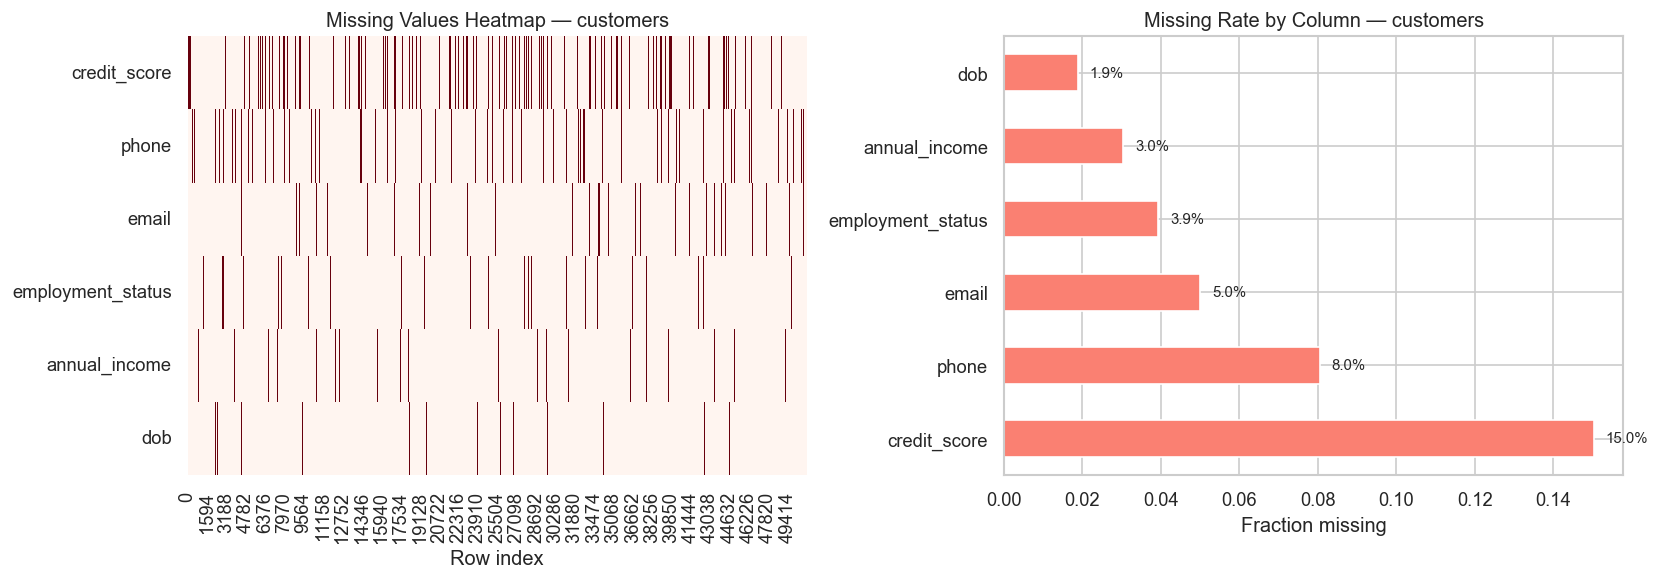

In [4]:
cust = tables["customers"]
cust_missing = cust.isnull().mean().sort_values(ascending=False)
cust_missing = cust_missing[cust_missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cust[cust_missing.index].isnull().T,
    cbar=False, yticklabels=True, cmap="Reds",
    ax=axes[0],
)
axes[0].set_title("Missing Values Heatmap — customers")
axes[0].set_xlabel("Row index")

cust_missing.plot.barh(ax=axes[1], color="salmon")
axes[1].set_title("Missing Rate by Column — customers")
axes[1].set_xlabel("Fraction missing")
for i, v in enumerate(cust_missing.values):
    axes[1].text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Data Type Issues

### Dollar signs in order amounts

Some `order_amount` values may be stored as strings with a `$` prefix.

In [5]:
orders = tables["orders"]

dollar_mask = orders["order_amount"].astype(str).str.contains(r"^\$", na=False)
n_dollar = dollar_mask.sum()
print(f"Order amounts with '$' prefix: {n_dollar:,} ({100*n_dollar/len(orders):.2f}%)")
display(orders.loc[dollar_mask, ["order_id", "order_amount"]].head(10))

Order amounts with '$' prefix: 7,843 (5.04%)


,order_id,order_amount
35,36,$387.01
40,41,$453.33
54,55,$49.84
176,178,$777.76
201,203,$408.39
212,214,$44.18
248,250,$186.92
285,287,$96.61
327,330,$177.53
332,335,$218.78


In [6]:
type_issues = []
for name, df in tables.items():
    for col in df.columns:
        if df[col].dtype == object:
            sample = df[col].dropna()
            if sample.empty:
                continue
            n_types = sample.apply(type).nunique()
            if n_types > 1:
                type_issues.append((name, col, n_types, sample.apply(type).value_counts().to_dict()))

if type_issues:
    print("Columns with mixed Python types:")
    for tbl, col, n, dist in type_issues:
        print(f"  {tbl}.{col}: {n} types — {dist}")
else:
    print("No mixed-type object columns detected (values may still have embedded symbols).")

No mixed-type object columns detected (values may still have embedded symbols).


## Duplicate Detection

Near-duplicate customer records are common in BNPL when users create multiple accounts to circumvent credit limits — sometimes legitimately (typos in re-registration), sometimes fraudulently (synthetic identity rings).

### Exact duplicates

In [7]:
for name, df in tables.items():
    n_dup = df.duplicated().sum()
    if n_dup > 0:
        print(f"{name}: {n_dup:,} exact duplicate rows")
    else:
        print(f"{name}: no exact duplicates")

customers: no exact duplicates
merchants: no exact duplicates
orders: no exact duplicates
payment_plans: no exact duplicates
installments: no exact duplicates
payments: no exact duplicates
credit_decisions: no exact duplicates
device_fingerprints: no exact duplicates
disputes: no exact duplicates
customer_segments_ground_truth: no exact duplicates


### Near-duplicate customers

We look for customers that share a normalized (lowercased, stripped) first+last name or a similar email, which could indicate typo-based near-duplicates.

In [8]:
cust = tables["customers"].copy()

name_cols = [c for c in cust.columns if "name" in c.lower()]
print(f"Name columns found: {name_cols}")

if len(name_cols) >= 2:
    cust["_norm_name"] = (
        cust[name_cols[0]].astype(str).str.lower().str.strip() + " " +
        cust[name_cols[1]].astype(str).str.lower().str.strip()
    )
elif len(name_cols) == 1:
    cust["_norm_name"] = cust[name_cols[0]].astype(str).str.lower().str.strip()

name_counts = cust["_norm_name"].value_counts()
dup_names = name_counts[name_counts > 1]
print(f"\nDistinct normalized names appearing more than once: {len(dup_names):,}")
print(f"Total customer rows involved in name-duplicates: {dup_names.sum():,}")
display(dup_names.head(15))

Name columns found: ['first_name', 'last_name']

Distinct normalized names appearing more than once: 12,364
Total customer rows involved in name-duplicates: 49,292


_norm_name
jacob ali           15
jessica myers       12
kathleen bennett    12
sandra parker       12
jessica gomez       12
ethan campbell      11
mei ramirez         11
sharon roberts      11
margaret mendoza    11
ama patel           11
ahmed reed          11
nicole roberts      11
joshua stewart      11
laura singh         11
brenda bennett      11
Name: count, dtype: int64

In [9]:
if "email" in cust.columns:
    cust["_email_norm"] = cust["email"].astype(str).str.lower().str.strip()
    cust["_email_base"] = cust["_email_norm"].str.replace(r"[^a-z0-9@.]", "", regex=True)
    email_counts = cust["_email_base"].value_counts()
    dup_emails = email_counts[(email_counts > 1) & (email_counts.index != "nan")]
    print(f"Normalized email addresses appearing more than once: {len(dup_emails):,}")
    print(f"Total rows involved: {dup_emails.sum():,}")
    display(dup_emails.head(10))

    sample_dup_email = dup_emails.index[0] if len(dup_emails) > 0 else None
    if sample_dup_email:
        print(f"\nExample cluster for email '{sample_dup_email}':")
        display(cust[cust["_email_base"] == sample_dup_email][name_cols + ["email", "address"]].head())

Normalized email addresses appearing more than once: 1,069
Total rows involved: 2,157


_email_base
altnan                            9
michellenguyen67@outlook.com      3
logan.kim86@yahoo.com             3
elijahsanders87@outlook.com       3
lauralong3@hotmail.com            3
sharonmartin71@yahoo.com          3
mariasmith2@outlook.com           3
christinejackson22@outlook.com    3
ryanrodriguez75@gmail.com         3
sharonrobinson49@icloud.com       3
Name: count, dtype: int64


Example cluster for email 'altnan':


,first_name,last_name,email,address
50023,Janet,Wilson,alt_nan,2761 Hill Rd
50056,Logan,Castillo,alt_nan,786 Hill Rd
50068,Anthony,Watson,alt_nan,5561 Meadow Ln
50098,Betty,Walker,alt_nan,3870 Highland Ave
50164,Linda,Murphy,alt_nan,3490 Washington Blvd


## Format Inconsistencies

### State format inconsistencies

In [10]:
if "state" in cust.columns:
    states = cust["state"].dropna().astype(str)
    abbrev_mask = states.str.match(r"^[A-Z]{2}$")
    n_abbrev = abbrev_mask.sum()
    n_full = (~abbrev_mask).sum()
    print(f"State abbreviations (e.g. 'CA'):  {n_abbrev:,}")
    print(f"Full state names (e.g. 'California'): {n_full:,}")
    print(f"\nSample full-name states:")
    display(states[~abbrev_mask].value_counts().head(10))

State abbreviations (e.g. 'CA'):  43,308
Full state names (e.g. 'California'): 7,692

Sample full-name states:


state
California        980
Texas             764
Florida           552
New York          505
Illinois          358
Ohio              330
Pennsylvania      328
Georgia           287
North Carolina    270
New Jersey        260
Name: count, dtype: int64

### Date format inconsistencies

In [11]:
def classify_date_format(series):
    iso_pat = r"^\d{4}-\d{2}-\d{2}"
    us_pat = r"^\d{2}/\d{2}/\d{4}"
    verbose_pat = r"^[A-Z][a-z]{2} \d{1,2}, \d{4}"
    s = series.dropna().astype(str)
    return pd.DataFrame({
        "ISO (YYYY-MM-DD)": [s.str.match(iso_pat).sum()],
        "US (MM/DD/YYYY)": [s.str.match(us_pat).sum()],
        "Verbose (Mon DD, YYYY)": [s.str.match(verbose_pat).sum()],
    })

if "signup_date" in cust.columns:
    print("signup_date formats:")
    display(classify_date_format(cust["signup_date"]))
    print("\nExamples:")
    for fmt, pat in [("ISO", r"^\d{4}-"), ("US", r"^\d{2}/"), ("Verbose", r"^[A-Z][a-z]{2} ")]:
        match = cust["signup_date"].dropna().astype(str).str.match(pat)
        sample = cust.loc[match[match].index[:1], "signup_date"].values
        if len(sample):
            print(f"  {fmt}: {sample[0]}")

signup_date formats:


,ISO (YYYY-MM-DD),US (MM/DD/YYYY),"Verbose (Mon DD, YYYY)"
0,45874,2591,2535



Examples:
  ISO: 2022-11-14
  US: 06/03/2022
  Verbose: Jul 15, 2023


In [12]:
inst = tables["installments"]
if "due_date" in inst.columns:
    print("installments.due_date formats:")
    display(classify_date_format(inst["due_date"]))

installments.due_date formats:


,ISO (YYYY-MM-DD),US (MM/DD/YYYY),"Verbose (Mon DD, YYYY)"
0,816826,43232,0


### Zip code issues (leading zeros)

In [13]:
if "zip_code" in cust.columns:
    zips = cust["zip_code"].dropna().astype(str)
    short_zips = zips[zips.str.len() < 5]
    print(f"Zip codes shorter than 5 characters (lost leading zeros): {len(short_zips):,}")
    if len(short_zips) > 0:
        display(
            cust.loc[short_zips.index, ["customer_id", "state", "zip_code"]]
            .head(10)
        )

Zip codes shorter than 5 characters (lost leading zeros): 655


,customer_id,state,zip_code
18,19,NJ,7408
67,68,CT,6029
243,244,MA,2268
391,392,New Jersey,7262
403,404,MA,2730
406,407,NJ,8366
417,418,NJ,7891
494,495,NJ,8314
528,529,MA,1852
545,546,CT,6023


## Referential Integrity

Orphaned records (e.g. installments pointing to non-existent plans) indicate either data pipeline failures or deliberate manipulation.

In [14]:
plans = tables["payment_plans"]
inst = tables["installments"]

valid_plan_ids = set(plans["plan_id"])
orphaned_mask = ~inst["plan_id"].isin(valid_plan_ids)
n_orphaned = orphaned_mask.sum()
print(f"Orphaned installments (plan_id not in payment_plans): {n_orphaned:,}")
print(f"Percentage of installments: {100*n_orphaned/len(inst):.2f}%")

if n_orphaned > 0:
    display(inst[orphaned_mask].head(5))

Orphaned installments (plan_id not in payment_plans): 4,300
Percentage of installments: 0.50%


,installment_id,plan_id,installment_number,amount_due,due_date,status,days_past_due
25,26,147426,2,209.87,2024-03-07,paid,0
567,568,139832,2,37.16,2023-04-07,late,1
617,618,139880,2,29.44,2024-01-04,paid,0
636,637,142730,3,27.02,2023-10-28,paid,0
936,937,146494,3,194.44,2024-06-25,missed,21


In [15]:
fk_checks = [
    ("orders", "customer_id", "customers", "customer_id"),
    ("orders", "merchant_id", "merchants", "merchant_id"),
    ("payment_plans", "order_id", "orders", "order_id"),
    ("payments", "installment_id", "installments", "installment_id"),
    ("installments", "plan_id", "payment_plans", "plan_id"),
    ("credit_decisions", "order_id", "orders", "order_id"),
    ("device_fingerprints", "order_id", "orders", "order_id"),
    ("disputes", "order_id", "orders", "order_id"),
]

fk_results = []
for child_tbl, child_col, parent_tbl, parent_col in fk_checks:
    child_vals = set(tables[child_tbl][child_col].dropna())
    parent_vals = set(tables[parent_tbl][parent_col].dropna())
    orphans = child_vals - parent_vals
    fk_results.append({
        "child": f"{child_tbl}.{child_col}",
        "parent": f"{parent_tbl}.{parent_col}",
        "orphan_keys": len(orphans),
    })

fk_df = pd.DataFrame(fk_results)
display(fk_df)

,child,parent,orphan_keys
0,orders.customer_id,customers.customer_id,0
1,orders.merchant_id,merchants.merchant_id,0
2,payment_plans.order_id,orders.order_id,0
3,payments.installment_id,installments.installment_id,0
4,installments.plan_id,payment_plans.plan_id,3417
5,credit_decisions.order_id,orders.order_id,0
6,device_fingerprints.order_id,orders.order_id,0
7,disputes.order_id,orders.order_id,0


## Outliers

### Negative and absurd order amounts

Negative amounts:  325 (0.21%)
Absurd amounts (>$50K): 478 (0.31%)


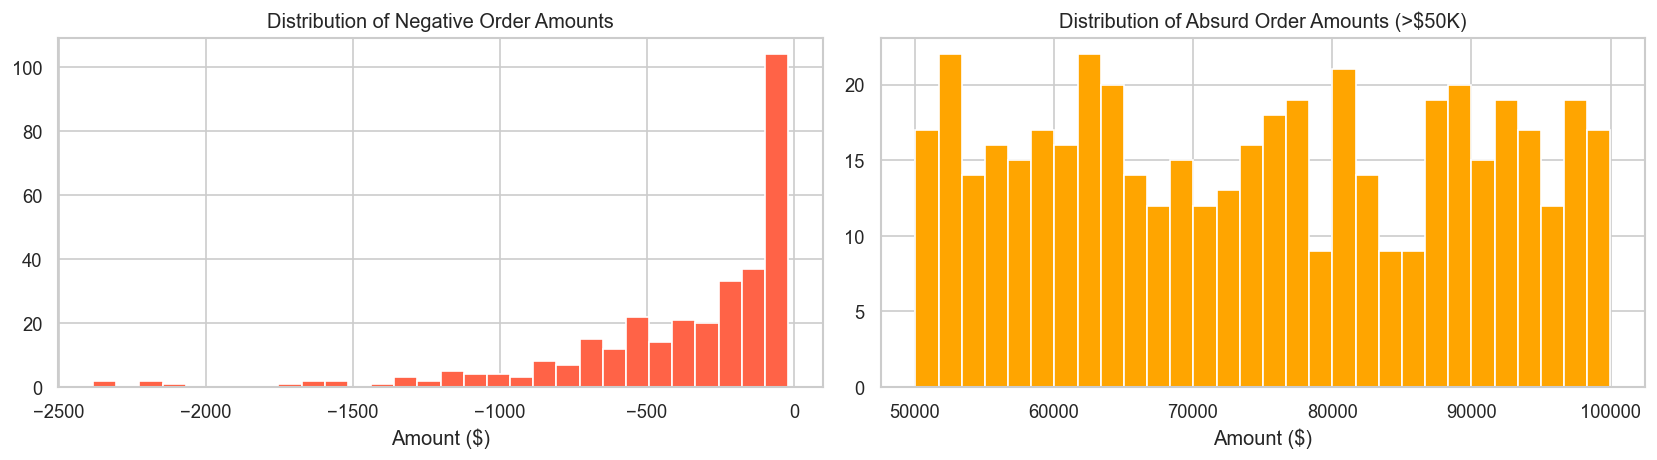

In [16]:
orders = tables["orders"].copy()
orders["amount_clean"] = (
    orders["order_amount"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

neg_mask = orders["amount_clean"] < 0
absurd_mask = orders["amount_clean"] > 50_000

print(f"Negative amounts:  {neg_mask.sum():,} ({100*neg_mask.mean():.2f}%)")
print(f"Absurd amounts (>$50K): {absurd_mask.sum():,} ({100*absurd_mask.mean():.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

orders.loc[neg_mask, "amount_clean"].hist(bins=30, ax=axes[0], color="tomato")
axes[0].set_title("Distribution of Negative Order Amounts")
axes[0].set_xlabel("Amount ($)")

orders.loc[absurd_mask, "amount_clean"].hist(bins=30, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Absurd Order Amounts (>$50K)")
axes[1].set_xlabel("Amount ($)")

plt.tight_layout()
plt.show()

### Future dates of birth

In [17]:
cust = tables["customers"].copy()

if "dob" in cust.columns:
    cust["dob_parsed"] = pd.to_datetime(cust["dob"], errors="coerce", dayfirst=False)
    future_dob = cust["dob_parsed"] > pd.Timestamp.now()
    print(f"Future DOBs: {future_dob.sum():,} ({100*future_dob.mean():.2f}%)")
    if future_dob.sum() > 0:
        display(cust.loc[future_dob, ["customer_id", "dob", "dob_parsed"]].head(10))

Future DOBs: 50 (0.10%)


,customer_id,dob,dob_parsed
3033,3034,2032-12-19,2032-12-19
3420,3421,2031-02-25,2031-02-25
4877,4878,2030-12-11,2030-12-11
5164,5165,2029-03-18,2029-03-18
5525,5526,2029-10-24,2029-10-24
5633,5634,2030-03-28,2030-03-28
6384,6385,2033-07-01,2033-07-01
6500,6501,2027-08-05,2027-08-05
7494,7495,2034-01-10,2034-01-10
9512,9513,2028-05-13,2028-05-13


### Payments dated before order dates

In [18]:
payments = tables["payments"].copy()
installments = tables["installments"].copy()
plans = tables["payment_plans"].copy()
orders_clean = tables["orders"].copy()

orders_clean["order_date_parsed"] = pd.to_datetime(
    orders_clean["order_date"], errors="coerce"
)

date_cols = [c for c in payments.columns if "date" in c.lower()]
pay_date_col = date_cols[0] if date_cols else None

if pay_date_col and "order_id" in plans.columns:
    payments["pay_date_parsed"] = pd.to_datetime(payments[pay_date_col], errors="coerce")
    pay_order = (
        payments
        .merge(installments[["installment_id", "plan_id"]], on="installment_id", how="left")
        .merge(plans[["plan_id", "order_id"]], on="plan_id", how="left")
        .merge(orders_clean[["order_id", "order_date_parsed"]], on="order_id", how="left")
    )
    before_mask = pay_order["pay_date_parsed"] < pay_order["order_date_parsed"]
    n_before = before_mask.sum()
    print(f"Payments dated before their order date: {n_before:,} ({100*n_before/len(pay_order):.2f}%)")
    if n_before > 0:
        display(pay_order.loc[before_mask, ["payment_id", pay_date_col, "order_id", "order_date_parsed"]].head(10))

Payments dated before their order date: 2,979 (0.48%)


,payment_id,payment_date,order_id,order_date_parsed
204,205,2022-09-12T18:14:46,60.0,2022-11-22 19:04:28
449,450,2021-11-25T16:38:37,124.0,2022-03-09 21:45:24
602,603,2022-12-27T22:34:31,157.0,2023-04-22 07:03:40
662,663,2024-03-12T07:30:33,183.0,2024-03-20 14:05:49
885,886,2022-10-09T07:50:15,230.0,2022-11-14 14:16:01
921,922,2023-11-18T13:00:19,239.0,2024-03-13 15:11:56
1097,1098,2023-07-19T18:17:00,270.0,2023-08-24 13:49:54
1380,1381,2023-06-18T17:21:46,347.0,2023-06-24 12:52:42
1731,1732,2022-08-23T21:19:25,429.0,2022-11-19 21:10:31
2243,2244,2023-10-31T08:10:40,549.0,2024-02-04 11:57:12


### Overpayments

In [19]:
amount_col = [c for c in payments.columns if "amount" in c.lower()]
pay_amt_col = amount_col[0] if amount_col else None

if pay_amt_col and "order_id" in plans.columns:
    payments["pay_amount_clean"] = (
        payments[pay_amt_col].astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
    )
    pay_with_plan = payments.merge(
        installments[["installment_id", "plan_id"]], on="installment_id", how="left"
    )
    total_paid = (
        pay_with_plan.groupby("plan_id")["pay_amount_clean"]
        .sum()
        .reset_index()
        .rename(columns={"pay_amount_clean": "total_paid"})
    )

    orders_clean["amount_clean"] = (
        orders_clean["order_amount"].astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
    )

    plan_order = plans[["plan_id", "order_id"]].merge(
        orders_clean[["order_id", "amount_clean"]], on="order_id", how="left"
    )
    plan_order = plan_order.merge(total_paid, on="plan_id", how="left")
    plan_order["overpay"] = plan_order["total_paid"] - plan_order["amount_clean"]

    overpay_mask = plan_order["overpay"] > 0.01
    print(f"Plans with overpayments: {overpay_mask.sum():,} ({100*overpay_mask.mean():.2f}%)")
    if overpay_mask.sum() > 0:
        display(
            plan_order.loc[overpay_mask]
            .sort_values("overpay", ascending=False)
            .head(10)
        )

Plans with overpayments: 33,873 (24.47%)


,plan_id,order_id,amount_clean,total_paid,overpay
65384,65385,74167,-1531.85,1531.84,3063.69
27172,27173,30773,-1547.32,1418.40,2965.72
120128,120129,136265,-1609.38,1207.05,2816.43
69953,69954,79375,-1333.15,1333.16,2666.31
100736,100737,114285,-1290.30,1290.28,2580.58
135197,135198,153294,-1231.76,1298.44,2530.20
72964,72965,82796,-1255.37,1082.79,2338.16
55569,55570,62955,-1133.15,1133.16,2266.31
110717,110718,125595,-1130.45,1130.44,2260.89
117232,117233,133015,-1031.98,1186.80,2218.78


## Distributions

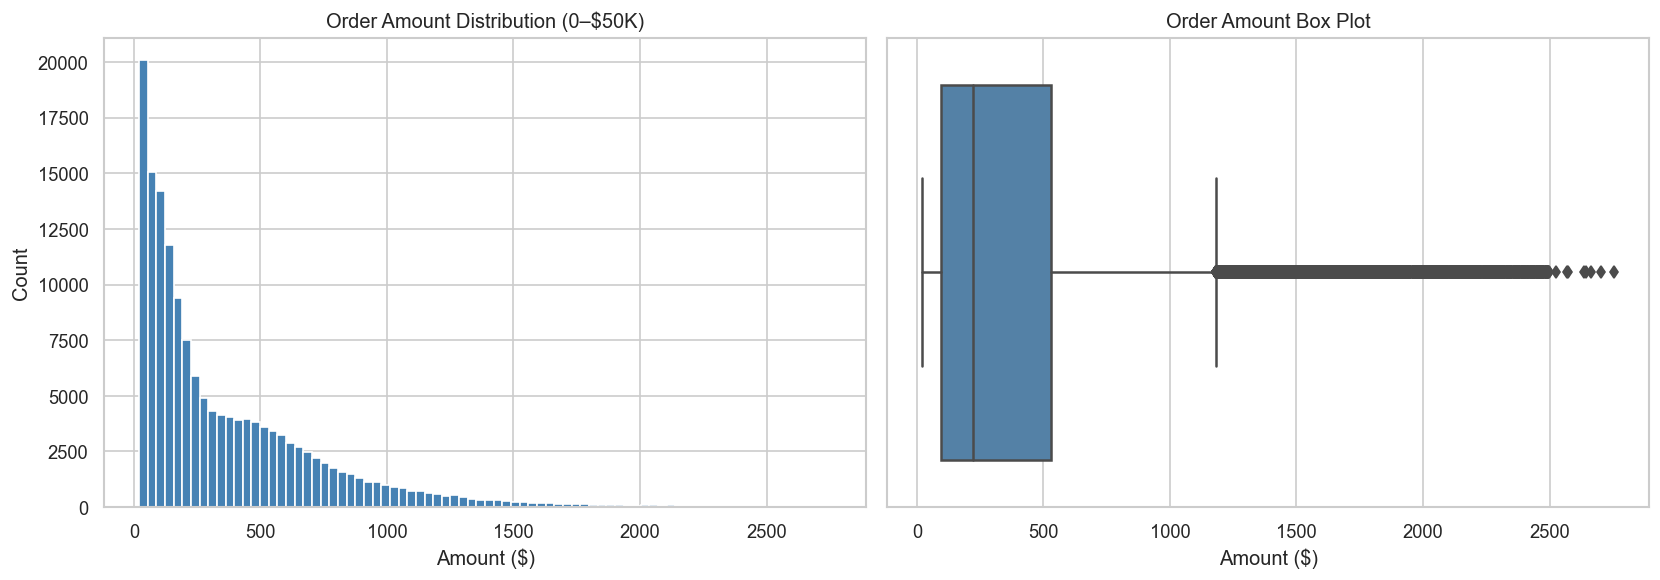

count    154947.000000
mean        364.896015
std         374.850169
min          20.000000
25%          96.500000
50%         222.660000
75%         530.120000
max        2755.570000
Name: amount_clean, dtype: float64


In [20]:
orders = tables["orders"].copy()
orders["amount_clean"] = (
    orders["order_amount"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

reasonable = orders[(orders["amount_clean"] > 0) & (orders["amount_clean"] <= 50_000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reasonable["amount_clean"].hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Order Amount Distribution (0–$50K)")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")

sns.boxplot(x=reasonable["amount_clean"], ax=axes[1], color="steelblue")
axes[1].set_title("Order Amount Box Plot")
axes[1].set_xlabel("Amount ($)")

plt.tight_layout()
plt.show()

print(reasonable["amount_clean"].describe())

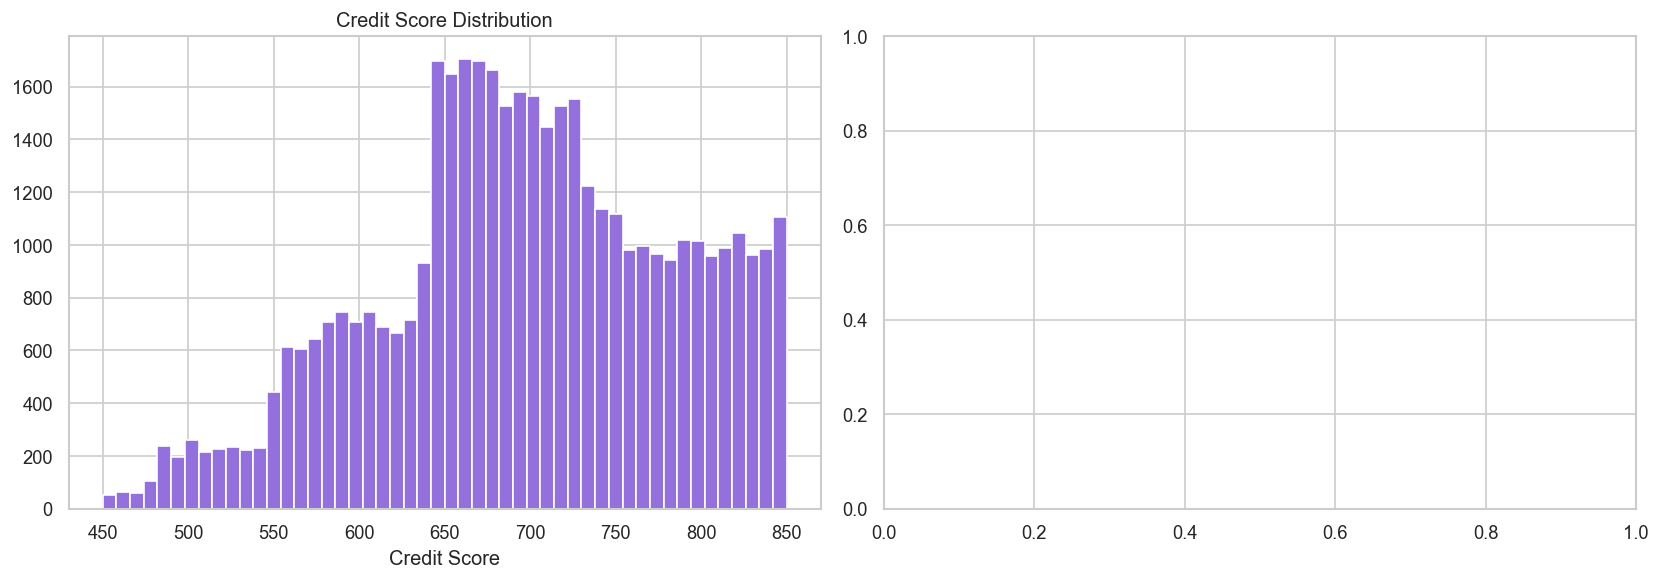

In [21]:
cust = tables["customers"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "credit_score" in cust.columns:
    cust["credit_score"].dropna().hist(bins=50, ax=axes[0], color="mediumpurple", edgecolor="white")
    axes[0].set_title("Credit Score Distribution")
    axes[0].set_xlabel("Credit Score")

if "income" in cust.columns:
    cust["income"].dropna().hist(bins=50, ax=axes[1], color="seagreen", edgecolor="white")
    axes[1].set_title("Income Distribution")
    axes[1].set_xlabel("Income ($)")

plt.tight_layout()
plt.show()

## Temporal Patterns

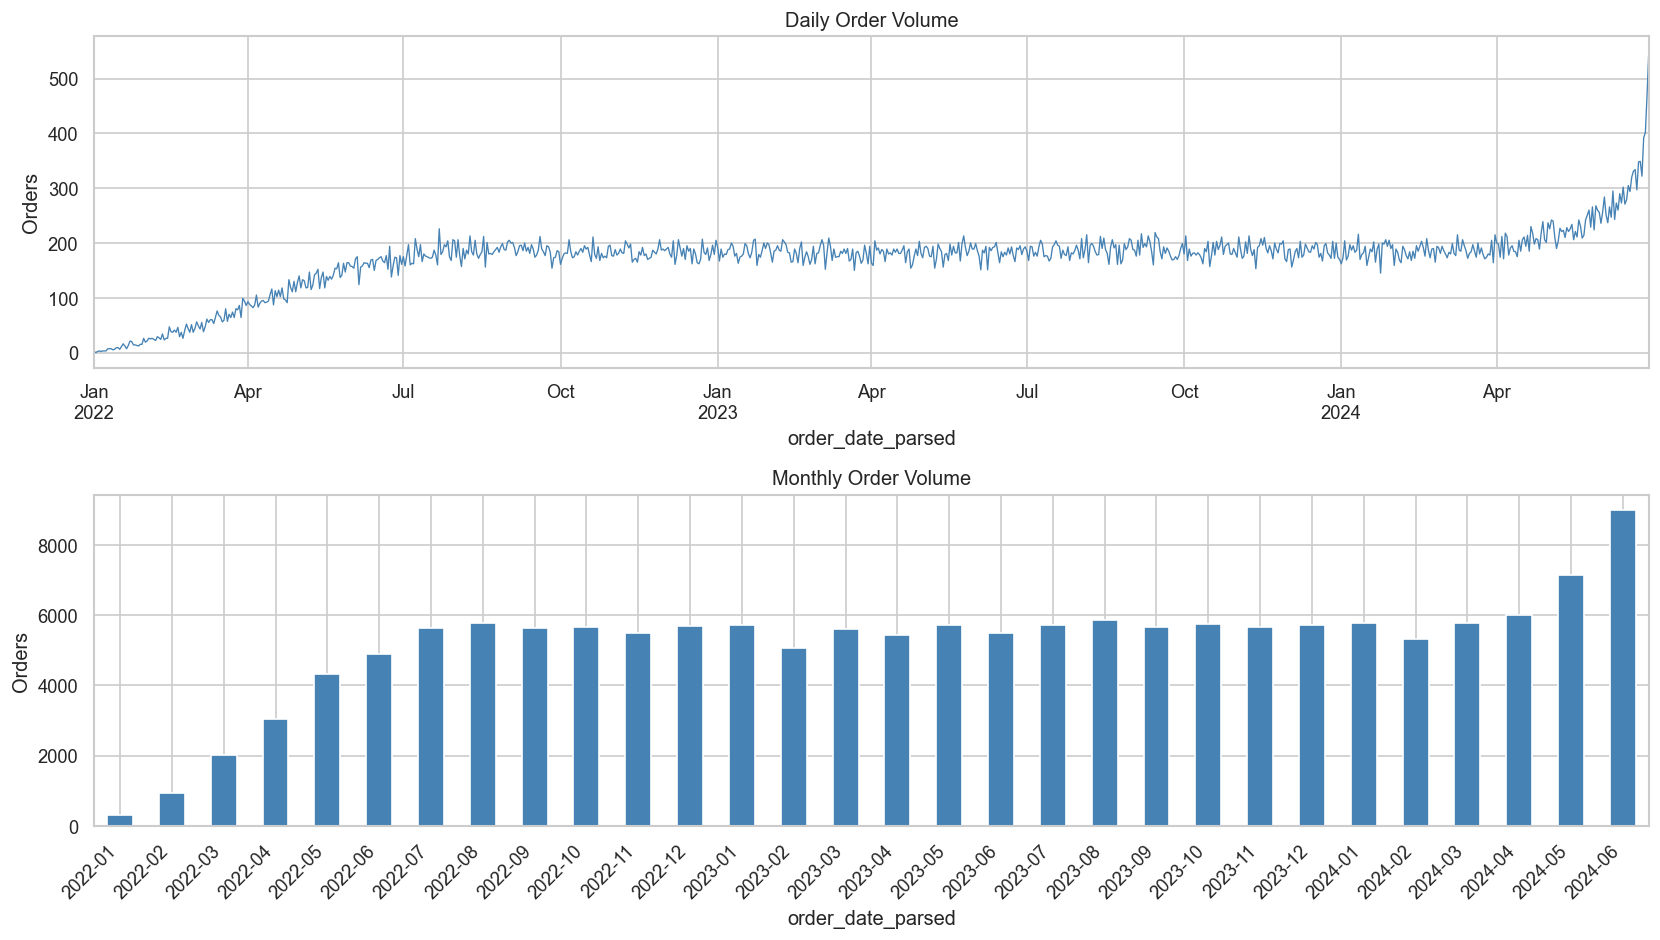

In [22]:
orders = tables["orders"].copy()
orders["order_date_parsed"] = pd.to_datetime(orders["order_date"], errors="coerce")

daily_vol = (
    orders.set_index("order_date_parsed")
    .resample("D")["order_id"]
    .count()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

daily_vol.plot(ax=axes[0], linewidth=0.8, color="steelblue")
axes[0].set_title("Daily Order Volume")
axes[0].set_ylabel("Orders")

monthly_vol = (
    orders.set_index("order_date_parsed")
    .resample("ME")["order_id"]
    .count()
)
monthly_vol.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Monthly Order Volume")
axes[1].set_ylabel("Orders")
axes[1].set_xticklabels(
    [d.strftime("%Y-%m") for d in monthly_vol.index], rotation=45, ha="right"
)

plt.tight_layout()
plt.show()

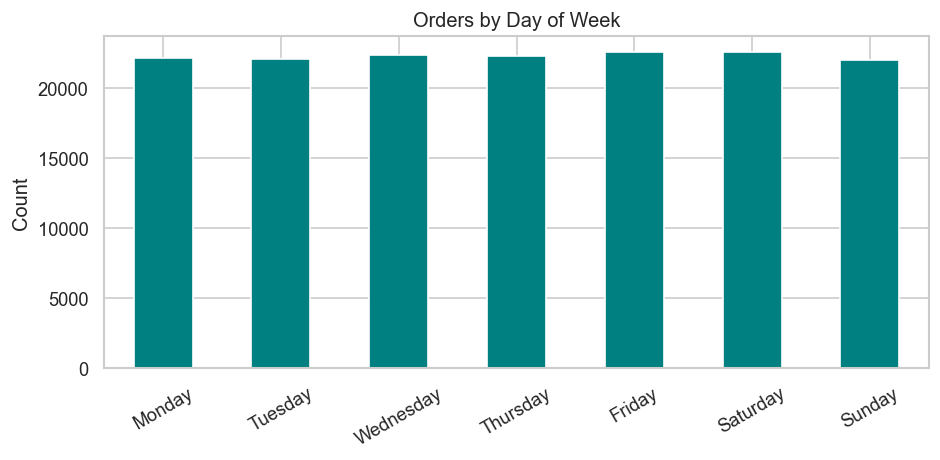

In [23]:
orders["dow"] = orders["order_date_parsed"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(8, 4))
orders["dow"].value_counts().reindex(dow_order).plot(kind="bar", ax=ax, color="teal", edgecolor="white")
ax.set_title("Orders by Day of Week")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Segment Analysis

In [24]:
seg = tables["customer_segments_ground_truth"]
print(f"Segments: {seg['segment'].nunique()} unique values")
display(seg["segment"].value_counts())

Segments: 5 unique values


segment
good_payer              30653
occasional_late         10234
slow_deterioration       5037
fraudster                2574
first_time_defaulter     2502
Name: count, dtype: int64

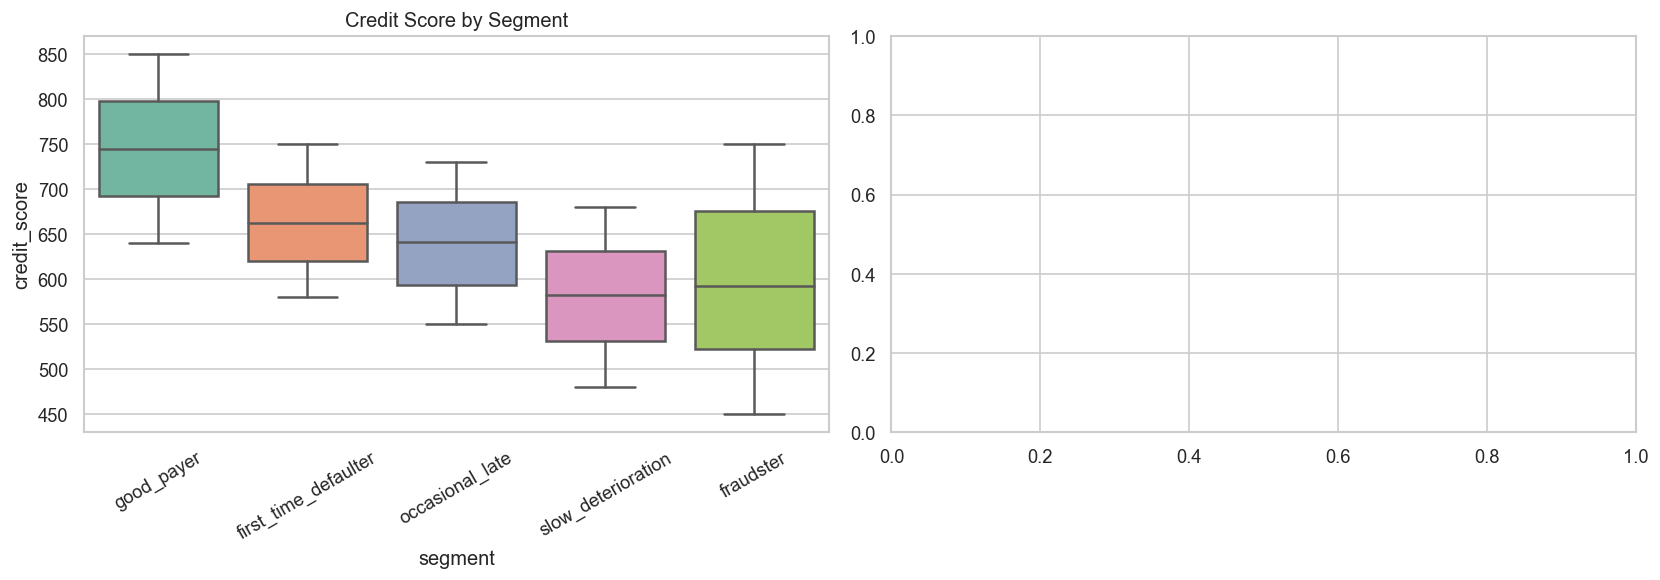

In [25]:
cust = tables["customers"].copy()
cust_seg = cust.merge(seg, on="customer_id", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "credit_score" in cust_seg.columns:
    sns.boxplot(data=cust_seg, x="segment", y="credit_score", ax=axes[0], palette="Set2")
    axes[0].set_title("Credit Score by Segment")
    axes[0].tick_params(axis="x", rotation=30)

if "income" in cust_seg.columns:
    sns.boxplot(data=cust_seg, x="segment", y="income", ax=axes[1], palette="Set2")
    axes[1].set_title("Income by Segment")
    axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

,n_orders,avg_amount,median_amount,total_amount
segment,,,,
first_time_defaulter,6094,578.20,209.84,3523536.68
fraudster,10992,888.20,407.69,9763083.16
good_payer,89279,580.99,216.31,51870551.14
occasional_late,29900,538.99,214.77,16115770.84
slow_deterioration,19485,557.57,218.48,10864292.65


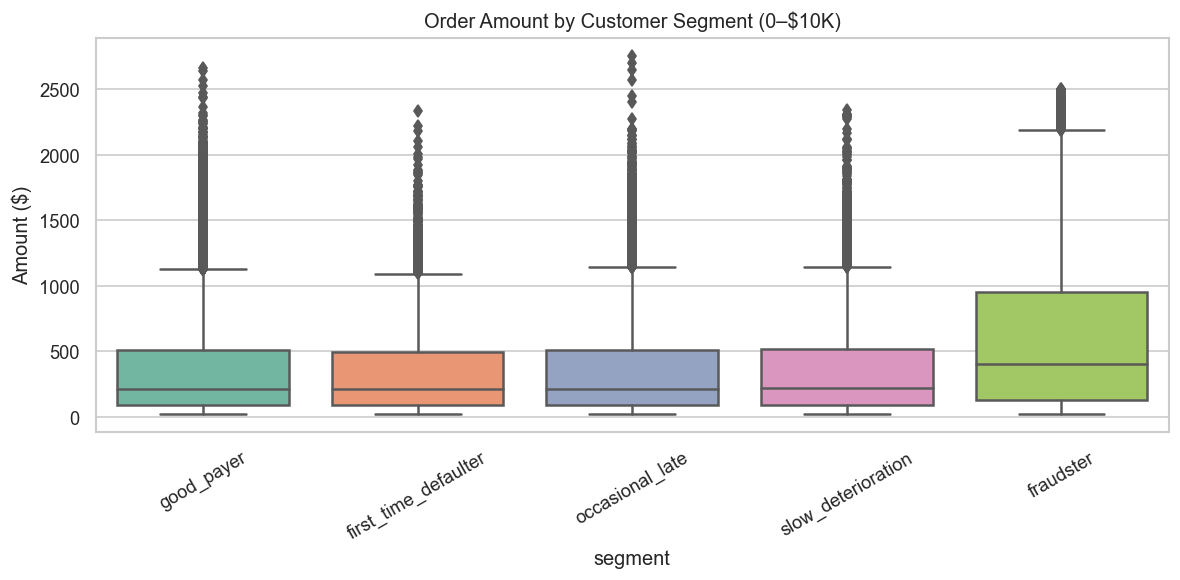

In [26]:
orders_clean = tables["orders"].copy()
orders_clean["amount_clean"] = (
    orders_clean["order_amount"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

order_seg = orders_clean.merge(
    seg, on="customer_id", how="inner"
)

seg_stats = (
    order_seg.groupby("segment")
    .agg(
        n_orders=("order_id", "count"),
        avg_amount=("amount_clean", "mean"),
        median_amount=("amount_clean", "median"),
        total_amount=("amount_clean", "sum"),
    )
    .round(2)
)
display(seg_stats)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=order_seg[order_seg["amount_clean"].between(0, 10_000)],
    x="segment", y="amount_clean", ax=ax, palette="Set2",
)
ax.set_title("Order Amount by Customer Segment (0–$10K)")
ax.set_ylabel("Amount ($)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Summary

In [27]:
issues = [
    ["Missing Values", "customers.credit_score", "~15% null", "High", "Impute or flag"],
    ["Missing Values", "customers.phone", "~8% null", "Medium", "Impute or allow null"],
    ["Missing Values", "customers.email", "~5% null", "Medium", "Impute or allow null"],
    ["Missing Values", "customers.employment_status", "~4% null", "Medium", "Impute or flag"],
    ["Missing Values", "customers.income", "~3% null", "Medium", "Impute or flag"],
    ["Missing Values", "customers.dob", "~2% null", "Low", "Impute or flag"],
    ["Near-Duplicates", "customers", "~1,000 records", "High", "Deduplicate with fuzzy matching"],
    ["Type Issue", "orders.order_amount", "~5% have '$' prefix", "High", "Strip '$' and cast to numeric"],
    ["Format Inconsistency", "customers.state", "Mix of abbreviations and full names", "Medium", "Standardize to abbreviations"],
    ["Format Inconsistency", "customers.signup_date", "ISO / US / verbose formats mixed", "Medium", "Parse all to datetime"],
    ["Format Inconsistency", "installments.due_date", "Multiple date formats", "Medium", "Parse all to datetime"],
    ["Format Inconsistency", "customers.zip_code", "Leading zeros lost in NE states", "Medium", "Zero-pad to 5 digits"],
    ["Referential Integrity", "installments.plan_id", "~4,000 orphaned records", "High", "Remove or investigate"],
    ["Outlier", "orders.order_amount", "~0.2% negative values", "High", "Investigate / remove"],
    ["Outlier", "orders.order_amount", "~0.3% absurd (>$50K)", "High", "Cap or investigate"],
    ["Outlier", "customers.dob", "~0.1% future dates", "Medium", "Correct or null out"],
    ["Temporal Anomaly", "payments date < order date", "~0.8% of payments", "High", "Investigate / correct"],
    ["Overpayment", "payments vs order_amount", "~0.5% of plans", "Medium", "Investigate / cap"],
]

summary_df = pd.DataFrame(issues, columns=["Category", "Location", "Extent", "Severity", "Suggested Action"])
display(summary_df)

,Category,Location,Extent,Severity,Suggested Action
0,Missing Values,customers.credit_score,~15% null,High,Impute or flag
1,Missing Values,customers.phone,~8% null,Medium,Impute or allow null
2,Missing Values,customers.email,~5% null,Medium,Impute or allow null
3,Missing Values,customers.employment_status,~4% null,Medium,Impute or flag
4,Missing Values,customers.income,~3% null,Medium,Impute or flag
5,Missing Values,customers.dob,~2% null,Low,Impute or flag
6,Near-Duplicates,customers,"~1,000 records",High,Deduplicate with fuzzy matching
7,Type Issue,orders.order_amount,~5% have '$' prefix,High,Strip '$' and cast to numeric
8,Format Inconsistency,customers.state,Mix of abbreviations and full names,Medium,Standardize to abbreviations
9,Format Inconsistency,customers.signup_date,ISO / US / verbose formats mixed,Medium,Parse all to datetime


In [28]:
conn.close()
print("Database connection closed.")

Database connection closed.
